In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import os

In [18]:
#  Standard CNN model
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)

        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

In [19]:
# Improve CNN model with batch normalization and dropout
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=47):
        super(ImprovedCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Dropout(0.3)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [20]:
# 2. LOAD DATASET
def load_data(dataset_name, batch_size=64):
    transform = transforms.ToTensor()

    if dataset_name == "MNIST":
        train_set = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
        test_set = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
    elif dataset_name == "FashionMNIST":
        train_set = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
        test_set = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)
    elif dataset_name == "KMNIST":
        train_set = datasets.KMNIST(root='./data', train=True, transform=transform, download=True)
        test_set = datasets.KMNIST(root='./data', train=False, transform=transform, download=True)
    elif dataset_name == "EMNIST":
        train_set = datasets.EMNIST(root='./data', split='balanced', train=True, transform=transform, download=True)
        test_set = datasets.EMNIST(root='./data', split='balanced', train=False, transform=transform, download=True)
    else:
        raise ValueError("Unsupported dataset name.")

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

In [21]:
# EVALUATE FUNCTION
def evaluate_model(model, test_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total

In [22]:
# TRAIN FUNCTION
def train_model(model, train_loader, test_loader, dataset_name="MNIST", epochs=5, lr=0.001, log_dir="runs"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    writer = SummaryWriter(log_dir=os.path.join(log_dir, dataset_name))
    example_images, _ = next(iter(train_loader))
    writer.add_graph(model, example_images.to(device))
    img_grid = torchvision.utils.make_grid(example_images[:16])
    writer.add_image(f"{dataset_name}_examples", img_grid)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train, total_train = 0, 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

            step = epoch * len(train_loader) + i
            if i % 100 == 99:
                writer.add_scalar("training loss", running_loss / 100, step)
                running_loss = 0.0
            if step % 300 == 0:
                for name, param in model.named_parameters():
                    writer.add_histogram(name, param, step)

        train_acc = correct_train / total_train
        val_acc = evaluate_model(model, test_loader, device)
        writer.add_scalars("Accuracy", {"Train": train_acc, "Validation": val_acc}, epoch)
        print(f"[{dataset_name}] Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

    writer.close()
    return model

In [23]:
# VISUALIZE TEST RESULTS
def visualize_results(model, test_loader, class_names=None, num_images=10):
    model.eval()
    device = next(model.parameters()).device
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    images = images.cpu().numpy()
    predicted = predicted.cpu().numpy()
    labels = labels.cpu().numpy()

    plt.figure(figsize=(num_images * 1.8, 2.5))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i][0], cmap='gray')
        plt.axis('off')

        pred = predicted[i]
        gt = labels[i]
        
        if class_names:
            pred_text = class_names[pred]
            gt_text = class_names[gt]
        else:
            pred_text = str(pred)
            gt_text = str(gt)

        # Highlight misclassified examples
        title_color = 'green' if pred == gt else 'red'
        plt.title(f"P:{pred_text}\nGT:{gt_text}", fontsize=8, color=title_color)

    plt.suptitle("Test Predictions vs Ground Truth")
    plt.tight_layout()
    plt.show()

In [24]:
def get_class_names(dataset_name):
    if dataset_name == "FashionMNIST":
        return ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    
    elif dataset_name == "EMNIST":
        return [
            '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
            'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
            'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T',
            'U', 'V', 'W', 'X', 'Y', 'Z',
            'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't'
        ]
    
    return None  # For MNIST or others

In [25]:
def run_training_pipeline(dataset_name="MNIST", epochs=5, lr=0.001, model_type="SimpleCNN"):
    # Create the model
    num_classes = 47 if dataset_name == "EMNIST" else 10
    if model_type == "SimpleCNN":
        model = SimpleCNN(num_classes=num_classes)
    elif model_type == "ImprovedCNN":
        model = ImprovedCNN(num_classes=num_classes)
    else:
        raise ValueError(f"Unsupported model_type: {model_type}")

    # Load dataset
    train_loader, test_loader = load_data(dataset_name)

    # Train model
    trained_model = train_model(model, train_loader, test_loader, dataset_name, epochs=epochs, lr=lr)

    # Visualize results
    class_names = get_class_names(dataset_name)
    visualize_results(trained_model, test_loader, class_names=class_names)

[MNIST] Epoch 1: Train Acc=0.9547, Val Acc=0.9836
[MNIST] Epoch 2: Train Acc=0.9832, Val Acc=0.9889
[MNIST] Epoch 3: Train Acc=0.9870, Val Acc=0.9887
[MNIST] Epoch 4: Train Acc=0.9891, Val Acc=0.9925
[MNIST] Epoch 5: Train Acc=0.9914, Val Acc=0.9891
[MNIST] Epoch 6: Train Acc=0.9926, Val Acc=0.9939
[MNIST] Epoch 7: Train Acc=0.9930, Val Acc=0.9930
[MNIST] Epoch 8: Train Acc=0.9934, Val Acc=0.9929
[MNIST] Epoch 9: Train Acc=0.9945, Val Acc=0.9917
[MNIST] Epoch 10: Train Acc=0.9950, Val Acc=0.9927
[MNIST] Epoch 11: Train Acc=0.9950, Val Acc=0.9930
[MNIST] Epoch 12: Train Acc=0.9955, Val Acc=0.9936
[MNIST] Epoch 13: Train Acc=0.9965, Val Acc=0.9932
[MNIST] Epoch 14: Train Acc=0.9966, Val Acc=0.9928
[MNIST] Epoch 15: Train Acc=0.9964, Val Acc=0.9924
[MNIST] Epoch 16: Train Acc=0.9970, Val Acc=0.9924
[MNIST] Epoch 17: Train Acc=0.9973, Val Acc=0.9938
[MNIST] Epoch 18: Train Acc=0.9974, Val Acc=0.9943
[MNIST] Epoch 19: Train Acc=0.9973, Val Acc=0.9894
[MNIST] Epoch 20: Train Acc=0.9974, Val 

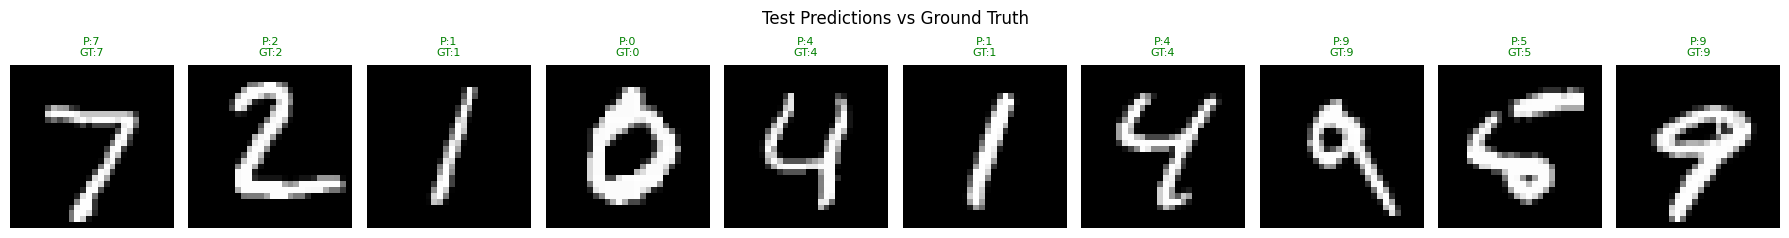

In [26]:
run_training_pipeline(dataset_name="MNIST", epochs=20, lr=0.0005, model_type="ImprovedCNN")

[FashionMNIST] Epoch 1: Train Acc=0.8433, Val Acc=0.8887
[FashionMNIST] Epoch 2: Train Acc=0.8940, Val Acc=0.8962
[FashionMNIST] Epoch 3: Train Acc=0.9092, Val Acc=0.9077
[FashionMNIST] Epoch 4: Train Acc=0.9165, Val Acc=0.9112
[FashionMNIST] Epoch 5: Train Acc=0.9236, Val Acc=0.9119
[FashionMNIST] Epoch 6: Train Acc=0.9315, Val Acc=0.9177
[FashionMNIST] Epoch 7: Train Acc=0.9357, Val Acc=0.9141
[FashionMNIST] Epoch 8: Train Acc=0.9396, Val Acc=0.9134
[FashionMNIST] Epoch 9: Train Acc=0.9436, Val Acc=0.9223
[FashionMNIST] Epoch 10: Train Acc=0.9459, Val Acc=0.9219
[FashionMNIST] Epoch 11: Train Acc=0.9507, Val Acc=0.9227
[FashionMNIST] Epoch 12: Train Acc=0.9537, Val Acc=0.9256
[FashionMNIST] Epoch 13: Train Acc=0.9567, Val Acc=0.9217
[FashionMNIST] Epoch 14: Train Acc=0.9583, Val Acc=0.9245
[FashionMNIST] Epoch 15: Train Acc=0.9616, Val Acc=0.9237
[FashionMNIST] Epoch 16: Train Acc=0.9623, Val Acc=0.9208
[FashionMNIST] Epoch 17: Train Acc=0.9652, Val Acc=0.9260
[FashionMNIST] Epoch 18

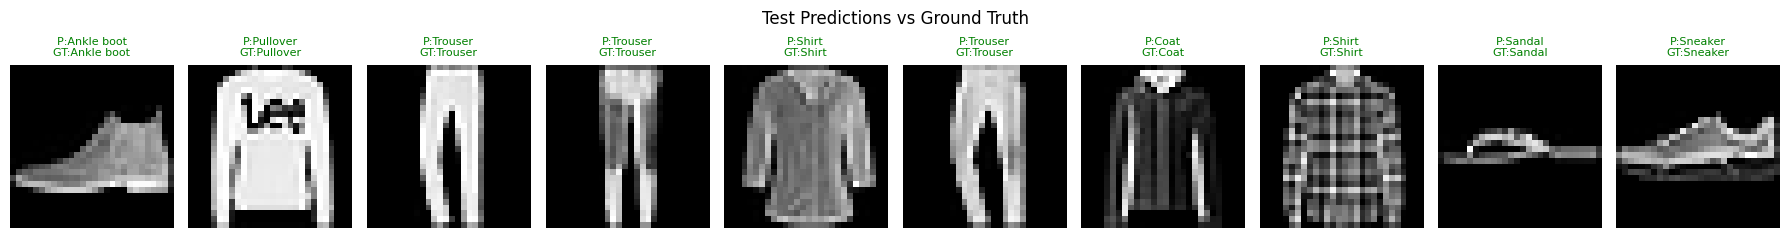

In [ ]:
run_training_pipeline(dataset_name="FashionMNIST", epochs=50, lr=0.0005, model_type="ImprovedCNN")

[EMNIST] Epoch 1: Train Acc=0.7724, Val Acc=0.8617
[EMNIST] Epoch 2: Train Acc=0.8515, Val Acc=0.8722
[EMNIST] Epoch 3: Train Acc=0.8653, Val Acc=0.8822
[EMNIST] Epoch 4: Train Acc=0.8727, Val Acc=0.8810
[EMNIST] Epoch 5: Train Acc=0.8786, Val Acc=0.8843
[EMNIST] Epoch 6: Train Acc=0.8827, Val Acc=0.8911
[EMNIST] Epoch 7: Train Acc=0.8867, Val Acc=0.8911
[EMNIST] Epoch 8: Train Acc=0.8894, Val Acc=0.8911
[EMNIST] Epoch 9: Train Acc=0.8935, Val Acc=0.8926
[EMNIST] Epoch 10: Train Acc=0.8948, Val Acc=0.8924
[EMNIST] Epoch 11: Train Acc=0.8960, Val Acc=0.8926
[EMNIST] Epoch 12: Train Acc=0.8992, Val Acc=0.8944
[EMNIST] Epoch 13: Train Acc=0.9009, Val Acc=0.8964
[EMNIST] Epoch 14: Train Acc=0.9031, Val Acc=0.8962
[EMNIST] Epoch 15: Train Acc=0.9048, Val Acc=0.8965
[EMNIST] Epoch 16: Train Acc=0.9063, Val Acc=0.8953
[EMNIST] Epoch 17: Train Acc=0.9074, Val Acc=0.8979
[EMNIST] Epoch 18: Train Acc=0.9095, Val Acc=0.8954
[EMNIST] Epoch 19: Train Acc=0.9091, Val Acc=0.8954
[EMNIST] Epoch 20: Tr

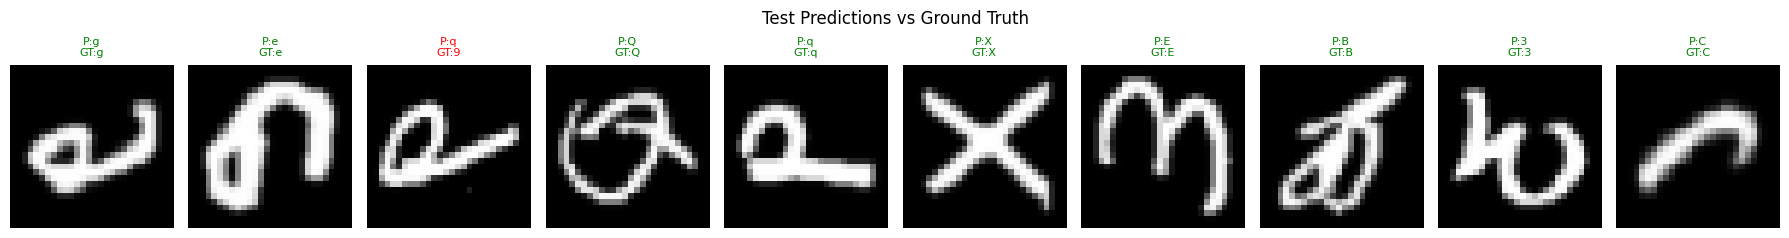

In [29]:
run_training_pipeline(dataset_name="EMNIST", epochs=40, lr=0.0005, model_type="ImprovedCNN")